In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.2f}'.format

In [70]:
df = pd.read_csv(r'C:\Users\rashid\Desktop\analysis_project\notebook\data\raw\all_player_profiles.csv')
df.head()
df.copy()

,player_id,name,league,position,market_value
0,804508,Viktor Gyökeres,Premier League,F,61000000.00
1,934235,Bukayo Saka,Premier League,F,126000000.00
2,794839,Gabriel Jesus,Premier League,F,21000000.00
3,922573,Gabriel Martinelli,Premier League,F,42000000.00
4,836705,Kai Havertz,Premier League,F,48000000.00
...,...,...,...,...,...
4178,807093,Fatih Kurucuk,Super Lig,D,265000.00
4179,283847,Ivo Grbić,Super Lig,G,1200000.00
4180,934507,Furkan Bekleviç,Super Lig,G,270000.00
4181,1634332,Kerem Yandal,Super Lig,G,NaN


In [71]:
df.shape

(4183, 5)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4183 entries, 0 to 4182
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   player_id     4183 non-null   int64  
 1   name          4183 non-null   object 
 2   league        4183 non-null   object 
 3   position      4182 non-null   object 
 4   market_value  4017 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 163.5+ KB


In [73]:
df["market_value"].describe()

count        4017.00
mean      9137744.82
std      16091774.26
min         10000.00
25%        860000.00
50%       3100000.00
75%      10500000.00
max     218000000.00
Name: market_value, dtype: float64

In [74]:
df.isnull().sum()

player_id         0
name              0
league            0
position          1
market_value    166
dtype: int64

In [75]:
df[df['position'].isnull()]

,player_id,name,league,position,market_value
1853,2516532,Hans-Dieter Wacker,Bundesliga,NaN,NaN


In [76]:
df[df['market_value'].isnull()]

,player_id,name,league,position,market_value
24,1842987,Khari Ranson,Premier League,G,NaN
65,1402850,Tyler Fletcher,Premier League,M,NaN
120,1462781,Kieran Morrison,Premier League,M,NaN
140,1861699,Ryan Kavuma-McQueen,Premier League,F,NaN
182,2248920,Luka Bentt,Premier League,M,NaN
...,...,...,...,...,...
4136,2169898,Ismaila Manga,Super Lig,M,NaN
4146,2169895,Diabel Ndoye,Super Lig,D,NaN
4168,2462525,Yaya Onogo,Super Lig,M,NaN
4181,1634332,Kerem Yandal,Super Lig,G,NaN


In [77]:
df.duplicated().sum()

np.int64(0)

In [78]:
df['position'].value_counts()

position
M    1505
D    1341
F     817
G     519
Name: count, dtype: int64

In [79]:
df['league'].value_counts()

league
Premier League    554
Serie A           552
LaLiga            543
Bundesliga        528
Super Lig         514
Eredivisie        501
Liga Portugal     497
Ligue 1           494
Name: count, dtype: int64

In [80]:
df.groupby('league')['player_id'].count()

league
Bundesliga        528
Eredivisie        501
LaLiga            543
Liga Portugal     497
Ligue 1           494
Premier League    554
Serie A           552
Super Lig         514
Name: player_id, dtype: int64

In [81]:
df['market_value'].describe()

count        4017.00
mean      9137744.82
std      16091774.26
min         10000.00
25%        860000.00
50%       3100000.00
75%      10500000.00
max     218000000.00
Name: market_value, dtype: float64

In [82]:
df.loc[df['market_value'].idxmax()]

player_id               839956
name            Erling Haaland
league          Premier League
position                     F
market_value      218000000.00
Name: 25, dtype: object

In [83]:
df.loc[df['market_value'].idxmin()]

player_id                   1157221
name            Georgiy Tunguliyadi
league                Liga Portugal
position                          D
market_value               10000.00
Name: 3523, dtype: object

In [84]:
#players whose market value is lower than 218000000 and higher than 200000000
df[(df['market_value'] < 218000000) & (df['market_value'] > 200000000)]

,player_id,name,league,position,market_value
557,1402912,Lamine Yamal,LaLiga,M,215000000.00
581,826643,Kylian Mbappé,LaLiga,F,212000000.00


In [85]:
df.groupby('league')['market_value'].mean().sort_values(ascending=False)

league
Premier League   23674185.39
LaLiga           10654812.72
Serie A           9583408.40
Bundesliga        9401215.51
Ligue 1           8508665.15
Liga Portugal     3787327.12
Super Lig         2871337.50
Eredivisie        2722066.65
Name: market_value, dtype: float64

In [86]:
df.groupby('position')['market_value'].mean().sort_values(ascending=False)

position
M   10937027.34
F   10854111.24
D    8067730.14
G    3707197.47
Name: market_value, dtype: float64

In [87]:
df['market_value'].mean()

np.float64(9137744.820014937)

In [88]:
df.head()

,player_id,name,league,position,market_value
0,804508,Viktor Gyökeres,Premier League,F,61000000.00
1,934235,Bukayo Saka,Premier League,F,126000000.00
2,794839,Gabriel Jesus,Premier League,F,21000000.00
3,922573,Gabriel Martinelli,Premier League,F,42000000.00
4,836705,Kai Havertz,Premier League,F,48000000.00


In [89]:
from statistics import median

q1 = df['market_value'].quantile(0.25)
q3 = df['market_value'].quantile(0.75)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
median = df['market_value'].quantile(0.5)
print(f"Lower fence: {lower_fence}")
print(f"Upper fence: {upper_fence}")
print(f"Median: {median}")
print(f"IQR", iqr)
print(f"Number of outliers: {df[(df['market_value'] < lower_fence) | (df['market_value'] > upper_fence)].shape[0]}")



Lower fence: -13600000.0
Upper fence: 24960000.0
Median: 3100000.0
IQR 9640000.0
Number of outliers: 410


In [90]:
maximum = df.loc[df['market_value'] == df['market_value'].max()]
minimum = df.loc[df['market_value'] == df['market_value'].min()]
print("Maximum market value:")
print(maximum[['name', 'market_value']])
print("\nMinimum market value:")
print(minimum[['name', 'market_value']])

Maximum market value:
              name  market_value
25  Erling Haaland  218000000.00

Minimum market value:
                     name  market_value
3523  Georgiy Tunguliyadi      10000.00


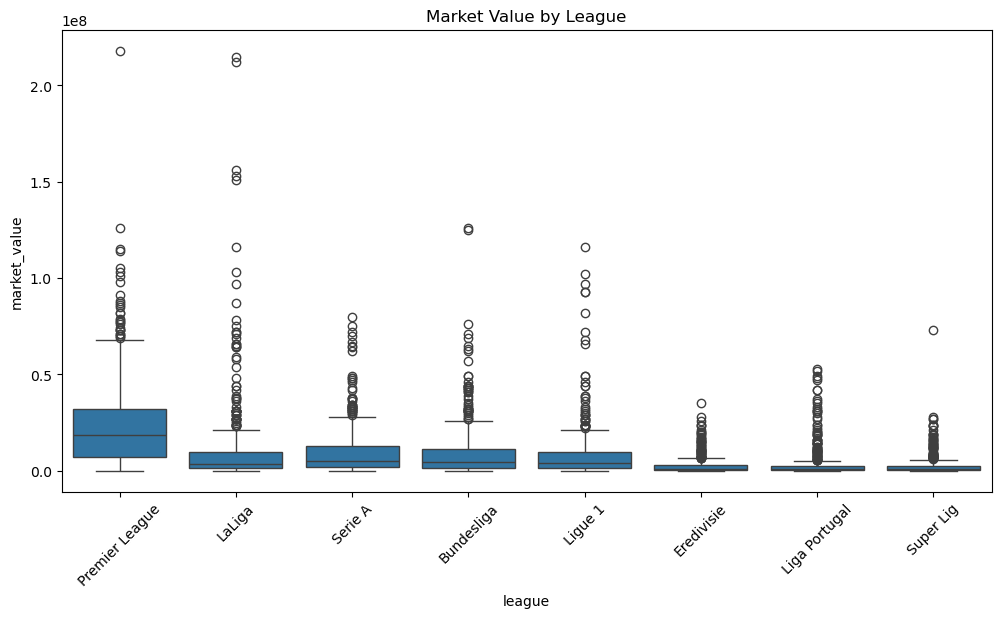

In [91]:
#boxplot of market value by league
plt.figure(figsize=(12,6))
sns.boxplot(x='league', y='market_value', data=df)
plt.xticks(rotation=45)
plt.title('Market Value by League')
plt.show()  


In [92]:
df[df['position'].isnull()]
#delete this row
df = df.dropna(subset=['position'])
df[df['position'].isnull()]

,player_id,name,league,position,market_value


In [93]:
#change null values in market value for each position to the mean of that position
df['market_value'] = df.groupby('position')['market_value'].transform(lambda x: x.fillna(x.mean()))

In [94]:
#give me mean of market value for each position
df.groupby('position')['market_value'].mean()


position
D    8067730.14
F   10854111.24
G    3707197.47
M   10937027.34
Name: market_value, dtype: float64

In [ ]:
df.head(25)

,player_id,name,league,position,market_value
0,804508,Viktor Gyökeres,Premier League,F,61000000.00
1,934235,Bukayo Saka,Premier League,F,126000000.00
2,794839,Gabriel Jesus,Premier League,F,21000000.00
3,922573,Gabriel Martinelli,Premier League,F,42000000.00
4,836705,Kai Havertz,Premier League,F,48000000.00
5,864921,Eberechi Eze,Premier League,F,63000000.00
6,135666,Leandro Trossard,Premier League,F,21000000.00
7,547410,Martin Ødegaard,Premier League,M,71000000.00
8,856714,Declan Rice,Premier League,M,114000000.00
9,966547,Noni Madueke,Premier League,M,54000000.00


In [96]:
df.isna().sum()

player_id       0
name            0
league          0
position        0
market_value    0
dtype: int64